In [1]:
import copy

class EMA:
    def __init__(self, beta=0.9999):
        self.beta = beta
        self.step = 0

    def update_model_average(self, ema_model, current_model):
        for current_params, ema_params in zip(current_model.parameters(), ema_model.parameters()):
            old_weight, up_weight = ema_params.data, current_params.data
            ema_params.data = self.update_average(old_weight, up_weight)

    def update_average(self, old, new):
        if old is None:
            return new
        return old * self.beta + (1 - self.beta) * new

In [2]:
import torch
import deepinv
import copy
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter

device = "cuda"
batch_size = 512
image_size = 32

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),  
    transforms.ToTensor(),
    transforms.Normalize((0.0,), (1.0,)) 
])

# train_loader = torch.utils.data.DataLoader(
#     datasets.MNIST(root="./data", train=True, download=True, transform=transform),
#     batch_size=batch_size,
#     shuffle=True
# )
train_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10(root="./data", train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True
)



In [4]:
lr = 1e-4
epochs = 100
model = deepinv.models.DiffUNet(in_channels=3, out_channels=3, pretrained=None).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
mse = deepinv.loss.MSE()  

#Diffusion Constants
beta_start = 0.0001
beta_end = 0.02
timesteps = 1000
betas = torch.linspace(beta_start, beta_end, timesteps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

ema = EMA(beta=0.999) # 0.999 is standard for image generation
ema_model = copy.deepcopy(model).eval().requires_grad_(False) # Clone it and freeze it

writer = SummaryWriter(log_dir="runs/diffusion_experiment")
global_step = 0

for epoch in range(epochs):
    model.train()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for data, _ in pbar:
        imgs = data.to(device)
        noise = torch.randn_like(imgs)
        t = torch.randint(0, timesteps, (imgs.size(0),), device=device)
        
        noised_imgs = (
            sqrt_alphas_cumprod[t, None, None, None] * imgs + sqrt_one_minus_alphas_cumprod[t, None, None, None] * noise
        )
        
        optimizer.zero_grad()

        unet_output = model(noised_imgs, t, type_t="timestep")
        
        # # Split the 6 channels into two chunks of 3 channels
        # # We only care about the first chunk (the estimated noise) for basic training
        estimated_noise, estimated_variance = torch.chunk(unet_output, 2, dim=1)

        # estimated_noise = model(noised_imgs, t, type_t="timestep")
        loss = mse(estimated_noise, noise).mean()
        loss.backward()
        optimizer.step()

        ema.update_model_average(ema_model, model)

        writer.add_scalar("Training/Loss", loss.item(), global_step)
        global_step += 1
        
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

writer.close()
torch.save(ema_model.state_dict(), "diffusion_model_ema.pth")

Epoch 100/100: 100%|██████████| 391/391 [00:49<00:00,  7.94it/s, loss=0.0151]


In [5]:
import torch
import deepinv
from pathlib import Path
device = "cuda"
image_size = 32

checkpoint_path = "/workspace/diffusion_basic_to_adv/diffusion_model_ema.pth"
model = deepinv.models.DiffUNet(
    in_channels=3, out_channels = 3, pretrained =  None
).to(device)

ckpt = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(ckpt, strict=False)

print("Model loaded successfully! Ready for generation.")
    

Model loaded successfully! Ready for generation.


In [6]:
beta_start = 0.0001
beta_end = 0.02
timesteps = 1000
betas = torch.linspace(beta_start, beta_end, timesteps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

model.eval()

n_samples = 32
with torch.no_grad():
    x = torch.randn(n_samples, 3, image_size, image_size).to(device)

    for t in reversed(range(timesteps)):
        t_tensor = torch.ones(n_samples, device=device).long() * t
        
        # 1. Get the full output from the U-Net
        unet_output = model(x, t_tensor, type_t="timestep")
        
        # 2. Slice it in half! We only want the noise prediction.
        predicted_noise, _ = torch.chunk(unet_output, 2, dim=1)
        
        alpha = alphas[t]
        alpha_cumprod = alphas_cumprod[t]
        beta = betas[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = 0

        # 3. The Math Step (Now with matching dimensions)
        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_cumprod)) * predicted_noise) + torch.sqrt(beta) * noise

# After the loop, 'x' contains your 32 fully generated cifar10 images!

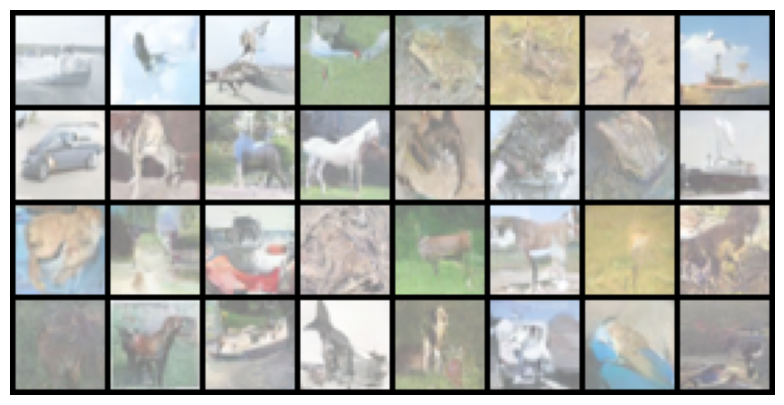

In [7]:
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# Normalize from [-1, 1] back to [0, 1]
x_display = (x.clamp(-1, 1) + 1) / 2 

# Create a beautiful grid of your 32 images
grid = vutils.make_grid(x_display, nrow=8)

# Plot it!
plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()

In [ ]:
!tensorboard --logdir=runs

CFG

In [4]:
from diffusers import UNet2DModel

lr = 1e-4
epochs = 150
model = UNet2DModel(
    sample_size=image_size,      # 32
    in_channels=3,               # RGB input
    out_channels=3,              # RGB output (Just the noise, no variance!)
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 256), # Standard capacity for CIFAR-10
    down_block_types=(
        "DownBlock2D", 
        "AttnDownBlock2D",       # Attention layers help it learn complex shapes!
        "AttnDownBlock2D", 
        "DownBlock2D"
    ),
    up_block_types=(
        "UpBlock2D", 
        "AttnUpBlock2D", 
        "AttnUpBlock2D", 
        "UpBlock2D"
    ),
    class_embed_type="timestep", # <--- THIS IS THE CFG MAGIC!
    num_class_embeds=11          # 10 real classes + 1 null class (class 10)
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
mse = deepinv.loss.MSE()  

#Diffusion Constants
beta_start = 0.0001
beta_end = 0.02
timesteps = 1000
betas = torch.linspace(beta_start, beta_end, timesteps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

ema = EMA(beta=0.999) # 0.999 is standard for image generation
ema_model = copy.deepcopy(model).eval().requires_grad_(False) # Clone it and freeze it

writer = SummaryWriter(log_dir="runs/diffusion_experiment")
global_step = 0

for epoch in range(epochs):
    model.train()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for data, labels in pbar: # <-- Catch the labels from the DataLoader!
        imgs = data.to(device)
        labels = labels.to(device)
        
        # 1. Label Dropout: 10% of the time, replace the real label with the Null label (10)
        # This forces the model to learn unconditional generation too!
        dropout_prob = 0.1
        dropout_mask = torch.rand(labels.shape, device=device) < dropout_prob
        labels[dropout_mask] = 10 # 10 becomes the "unconditional" token
        
        noise = torch.randn_like(imgs)
        t = torch.randint(0, timesteps, (imgs.size(0),), device=device)
        
        noised_imgs = (
            sqrt_alphas_cumprod[t, None, None, None] * imgs + 
            sqrt_one_minus_alphas_cumprod[t, None, None, None] * noise
        )
        
        optimizer.zero_grad()

            # The diffusers model requires explicitly naming the arguments
            # .sample pulls the actual tensor out of the diffusers output object
        estimated_noise = model(
                sample=noised_imgs, 
                timestep=t, 
                class_labels=labels
            ).sample
            
            # No more torch.chunk needed! We just calculate the loss directly.
        loss = mse(estimated_noise, noise).mean()
            
        loss.backward()
        optimizer.step()
        ema.update_model_average(ema_model, model)

        writer.add_scalar("Training/Loss", loss.item(), global_step)
        global_step += 1
            
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

writer.close()
torch.save(ema_model.state_dict(), "diffusion_model_ema.pth")

Epoch 1/150:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 150/150: 100%|██████████| 98/98 [00:43<00:00,  2.23it/s, loss=0.0212]


In [6]:
import torch
import deepinv
from pathlib import Path
device = "cuda"
image_size = 32

checkpoint_path = "/workspace/diffusion_basic_to_adv/diffusion_model_ema.pth"
model = UNet2DModel(
    sample_size=image_size,      # 32
    in_channels=3,               # RGB input
    out_channels=3,              # RGB output (Just the noise, no variance!)
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 256), # Standard capacity for CIFAR-10
    down_block_types=(
        "DownBlock2D", 
        "AttnDownBlock2D",       # Attention layers help it learn complex shapes!
        "AttnDownBlock2D", 
        "DownBlock2D"
    ),
    up_block_types=(
        "UpBlock2D", 
        "AttnUpBlock2D", 
        "AttnUpBlock2D", 
        "UpBlock2D"
    ),
    class_embed_type="timestep", # <--- THIS IS THE CFG MAGIC!
    num_class_embeds=11          # 10 real classes + 1 null class (class 10)
).to(device)

ckpt = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(ckpt, strict=False)

print("Model loaded successfully! Ready for generation.")
    

beta_start = 0.0001
beta_end = 0.02
timesteps = 1000
betas = torch.linspace(beta_start, beta_end, timesteps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

model.eval() # Or use your loaded ema_model.eval()

n_samples = 32
w = 5.0 # Guidance Scale! Higher = sharper shapes, but less variety.
target_class = 3 # CIFAR-10 Class 3 is 'Cat'

with torch.no_grad():
    x = torch.randn(n_samples, 3, image_size, image_size).to(device)

    # 1. Setup our labels: Half Conditional (Cat), Half Unconditional (Null)
    # We duplicate x later to process both simultaneously for speed
    labels_cond = torch.full((n_samples,), target_class, device=device, dtype=torch.long)
    labels_uncond = torch.full((n_samples,), 10, device=device, dtype=torch.long)

    for t in reversed(range(timesteps)):
        t_tensor = torch.ones(n_samples, device=device).long() * t
        
        # 2. Double the inputs so we can process conditional and unconditional in one pass
        x_doubled = torch.cat([x, x], dim=0)
        t_doubled = torch.cat([t_tensor, t_tensor], dim=0)
        y_doubled = torch.cat([labels_cond, labels_uncond], dim=0)
        
        predicted_noise = model(
            sample=x_doubled, 
            timestep=t_doubled, 
            class_labels=y_doubled
        ).sample
        
        # 4. Split the predictions back apart
        noise_cond, noise_uncond = torch.chunk(predicted_noise, 2, dim=0)
        
        # 5. THE MASTER CFG EQUATION!
        # Push the vector away from unconditional and towards the conditional
        cfg_noise = noise_uncond + w * (noise_cond - noise_uncond)
        
        # 6. Proceed with the standard mathematical step using our new CFG noise
        alpha = alphas[t]
        alpha_cumprod = alphas_cumprod[t]
        beta = betas[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = 0

        # Note: We apply the math to 'x', not 'x_doubled'
        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_cumprod)) * cfg_noise) + torch.sqrt(beta) * noise

Model loaded successfully! Ready for generation.


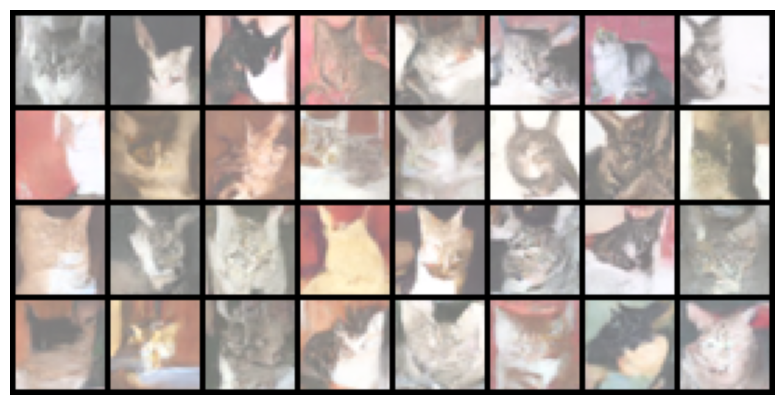

In [7]:
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# Normalize from [-1, 1] back to [0, 1]
x_display = (x.clamp(-1, 1) + 1) / 2 

# Create a beautiful grid of your 32 images
grid = vutils.make_grid(x_display, nrow=8)

# Plot it!
plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()

In [8]:
n_samples = 32
w = 5.0 # Guidance Scale! Higher = sharper shapes, but less variety.
target_class = 8 # CIFAR-10 Class 3 is 'Cat'

with torch.no_grad():
    x = torch.randn(n_samples, 3, image_size, image_size).to(device)

    # 1. Setup our labels: Half Conditional (Cat), Half Unconditional (Null)
    # We duplicate x later to process both simultaneously for speed
    labels_cond = torch.full((n_samples,), target_class, device=device, dtype=torch.long)
    labels_uncond = torch.full((n_samples,), 10, device=device, dtype=torch.long)

    for t in reversed(range(timesteps)):
        t_tensor = torch.ones(n_samples, device=device).long() * t
        
        # 2. Double the inputs so we can process conditional and unconditional in one pass
        x_doubled = torch.cat([x, x], dim=0)
        t_doubled = torch.cat([t_tensor, t_tensor], dim=0)
        y_doubled = torch.cat([labels_cond, labels_uncond], dim=0)
        
        predicted_noise = model(
            sample=x_doubled, 
            timestep=t_doubled, 
            class_labels=y_doubled
        ).sample
        
        # 4. Split the predictions back apart
        noise_cond, noise_uncond = torch.chunk(predicted_noise, 2, dim=0)
        
        # 5. THE MASTER CFG EQUATION!
        # Push the vector away from unconditional and towards the conditional
        cfg_noise = noise_uncond + w * (noise_cond - noise_uncond)
        
        # 6. Proceed with the standard mathematical step using our new CFG noise
        alpha = alphas[t]
        alpha_cumprod = alphas_cumprod[t]
        beta = betas[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = 0

        # Note: We apply the math to 'x', not 'x_doubled'
        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_cumprod)) * cfg_noise) + torch.sqrt(beta) * noise

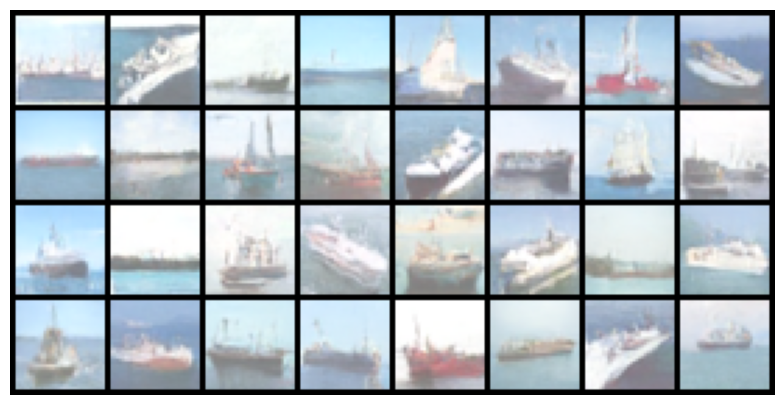

In [9]:
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# Normalize from [-1, 1] back to [0, 1]
x_display = (x.clamp(-1, 1) + 1) / 2 

# Create a beautiful grid of your 32 images
grid = vutils.make_grid(x_display, nrow=8)

# Plot it!
plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()

In [ ]:
!tensorboard --logdir=runs